## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")
df.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


## Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

## Dataset Shape

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1048575
Columns: 26


## Missing Values

In [5]:
df.isnull().sum()

item_id                   464051
status                    464066
created_at                464051
sku                       464071
price                     464051
qty_ordered               464051
grand_total               464051
increment_id              464051
category_name_1           464215
sales_commission_code     601229
discount_amount           464051
payment_method            464051
Working Date              464051
BI Status                 464051
 MV                       464051
Year                      464051
Month                     464051
Customer Since            464062
M-Y                       464051
FY                        464051
Customer ID               464062
Unnamed: 21              1048575
Unnamed: 22              1048575
Unnamed: 23              1048575
Unnamed: 24              1048575
Unnamed: 25              1048575
dtype: int64

## Handle Missing Values

In [6]:
df = df.dropna(subset=['Customer ID'])
df = df.fillna("Unknown")

## Remove Duplicates

In [7]:
df = df.drop_duplicates()

## Convert Data Types

In [8]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['Customer ID'] = df['Customer ID'].astype(int)
df['grand_total'] = pd.to_numeric(df['grand_total'], errors='coerce')

In [9]:
df.shape

(584513, 26)

## Order Status Count

In [10]:
df['status'].value_counts()

status
complete          233685
canceled          201244
received           77289
order_refunded     59524
refund              8050
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
processing            33
holded                31
Unknown               15
fraud                 10
pending_paypal         7
exchange               4
\N                     4
Name: count, dtype: int64

## Visualization of Order StatuS

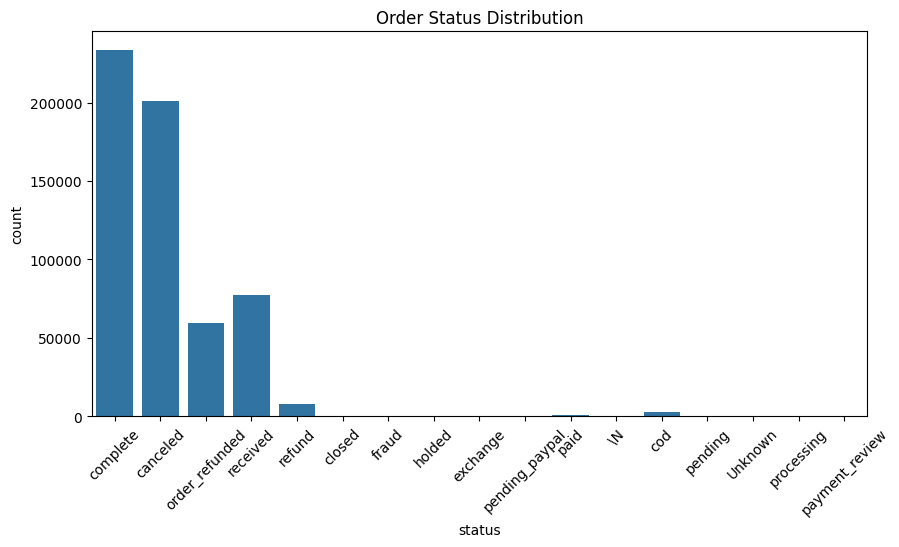

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['status'])
plt.xticks(rotation=45)
plt.title("Order Status Distribution")
plt.show()

## Top Product Categories

In [12]:
top_categories = df['category_name_1'].value_counts().head(10)
top_categories

category_name_1
Mobiles & Tablets    115710
Men's Fashion         92219
Women's Fashion       59720
Appliances            52413
Superstore            43613
Beauty & Grooming     41494
Soghaat               34011
Others                29212
Home & Living         26504
Entertainment         26326
Name: count, dtype: int64

## Category Visualization

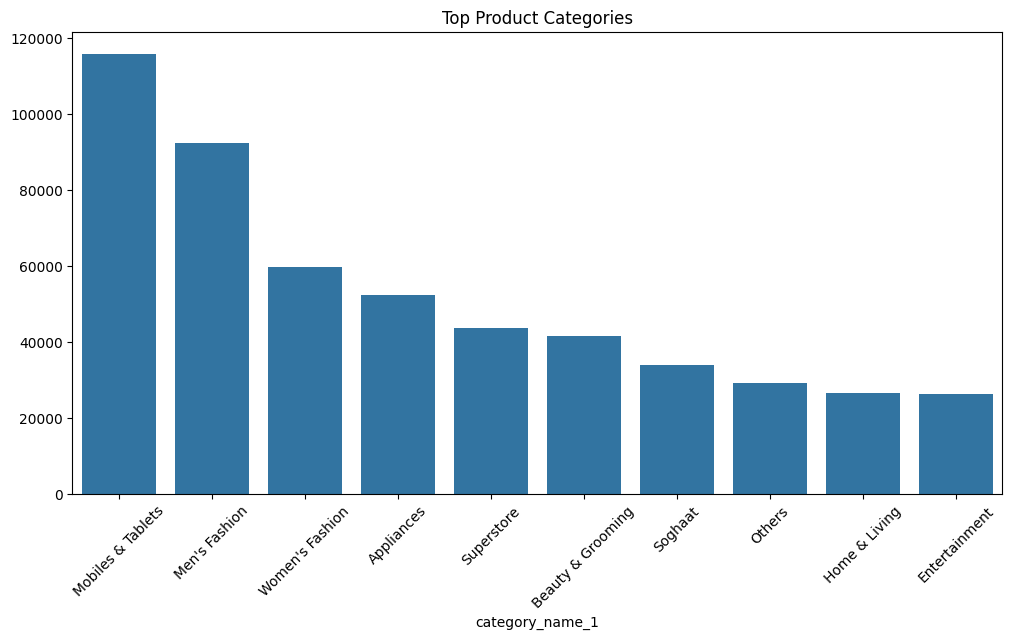

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.xticks(rotation=45)
plt.title("Top Product Categories")
plt.show()

## Payment Methods

In [14]:
df['payment_method'].value_counts()

payment_method
cod                  271955
Payaxis               97640
Easypay               82896
jazzwallet            35145
easypay_voucher       31176
bankalfalah           23065
jazzvoucher           15633
Easypay_MA            14027
customercredit         7555
apg                    1758
ublcreditcard           882
cashatdoorstep          732
mcblite                 723
mygateway               669
internetbanking         472
productcredit           125
marketingexpense         45
financesettlement        15
Name: count, dtype: int64

## Payment Method Visualization

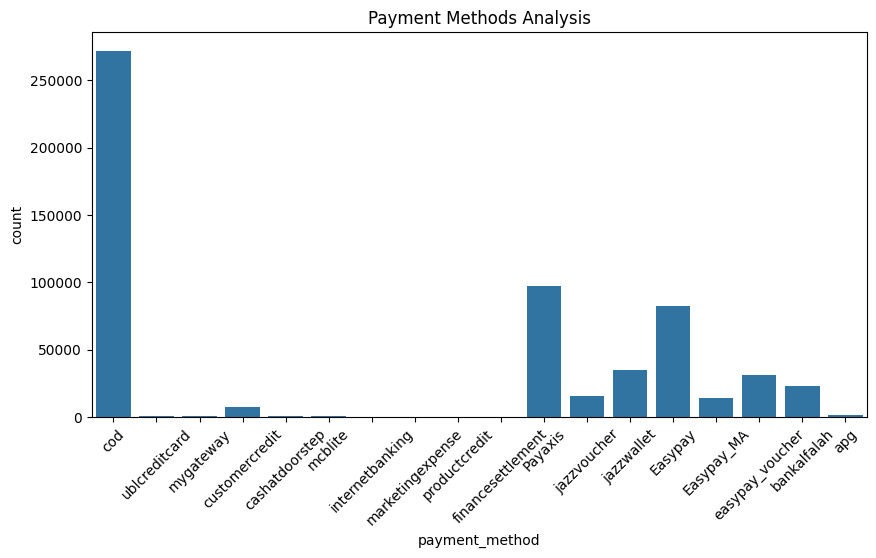

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['payment_method'])
plt.xticks(rotation=45)
plt.title("Payment Methods Analysis")
plt.show()

## Top Customers

In [16]:
top_customers = df.groupby('Customer ID')['grand_total'].sum().sort_values(ascending=False).head(10)
top_customers

Customer ID
5032      72150379.65
50387     35776000.00
111057    31338185.00
109038    28341357.57
110215    21969066.00
10654     19496005.00
113694    16531260.24
39707     16463501.80
26527     12502191.00
8963      12421437.60
Name: grand_total, dtype: float64

## Top Customers Visualization

# Feature Engineering

## Latest Date

In [17]:
latest_date = df['created_at'].max()
latest_date

Timestamp('2018-08-28 00:00:00')

## Create RFM Table

In [18]:
latest_date = df['created_at'].max()

rfm = df.groupby('Customer ID').agg({
    'created_at': lambda x: (latest_date - x.max()).days,
    'increment_id': 'count',
    'grand_total': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

## Rename Columns

In [19]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,788,1,1950.00
2,641,2,510.00
3,466,5,7430.00
4,1,428,2567596.45
5,788,1,1110.00


In [20]:
rfm.describe()

,Recency,Frequency,Monetary
count,115326.000000,115326.000000,1.153260e+05
mean,354.696781,5.068354,4.323649e+04
std,207.107491,23.073603,3.739391e+05
min,0.000000,1.000000,0.000000e+00
25%,172.000000,1.000000,1.310000e+03
50%,289.000000,2.000000,4.900000e+03
75%,530.000000,4.000000,2.172600e+04
max,788.000000,2524.000000,7.215038e+07


## Scaling Features

In [21]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled.shape

(115326, 3)

## Elbow Method

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

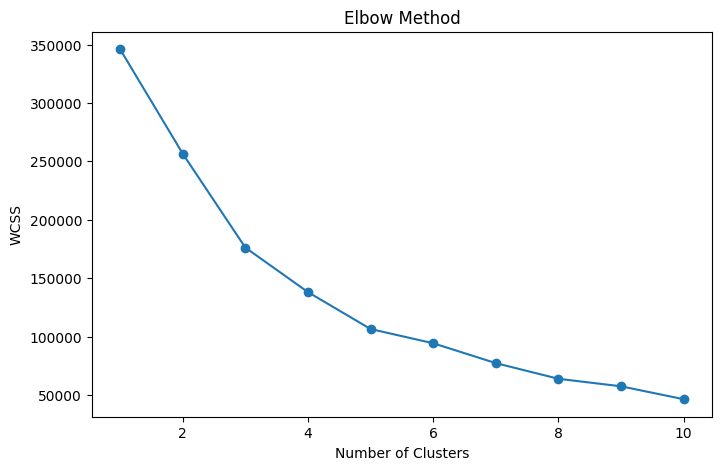

In [22]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

    plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Train K-Means Model

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'].value_counts()

Cluster
1    67542
0    47698
2       81
3        5
Name: count, dtype: int64

In [24]:
kmeans.cluster_centers_

array([[ 1.04008307e+00, -9.17937152e-02, -7.01663362e-02],
       [-7.36065026e-01,  3.36576025e-02,  2.69413460e-02],
       [-7.89862205e-01,  2.59147470e+01,  1.27190912e+01],
       [-9.32354584e-01,  3.65491300e+00,  1.01278336e+02]])

# PCA Dimensionality Reduction

## Apply PCA

In [25]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(rfm_scaled)

## PCA DataFrame

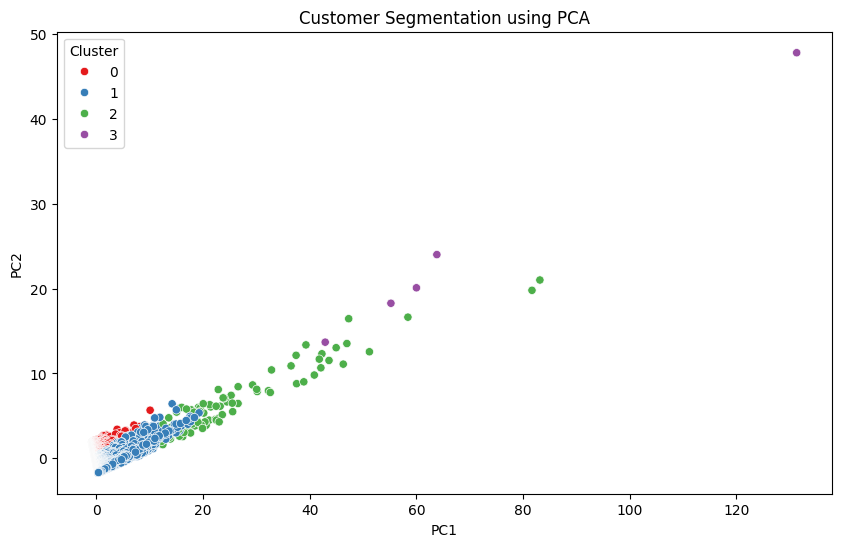

In [26]:
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])

pca_df['Cluster'] = rfm['Cluster'].values

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Customer Segmentation using PCA")
plt.show()

##  Cluster Analysis

In [27]:
cluster_analysis = rfm.groupby('Cluster').mean()

cluster_analysis

,Recency,Frequency,Monetary
Cluster,,,
0,570.483689,2.946874,1.697807e+04
1,202.519055,5.843209,5.327272e+04
2,191.111111,603.012346,4.799381e+06
3,161.600000,89.400000,3.791500e+07


## Heatmap

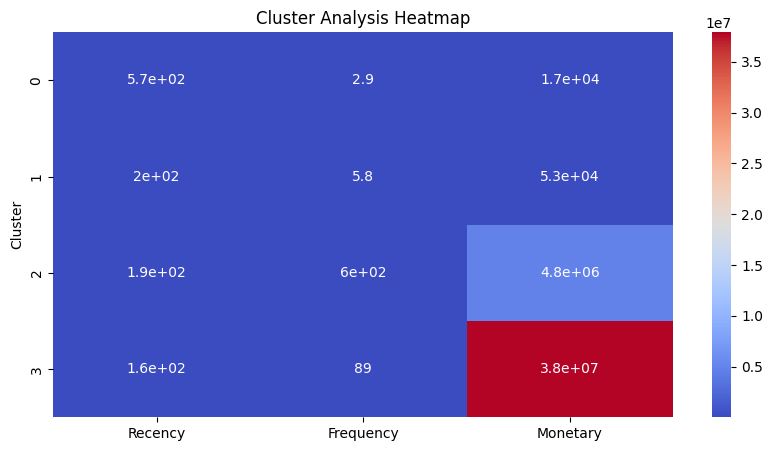

In [28]:
plt.figure(figsize=(10,5))

sns.heatmap(cluster_analysis, annot=True, cmap='coolwarm')

plt.title("Cluster Analysis Heatmap")
plt.show()

## Revenue by Cluster

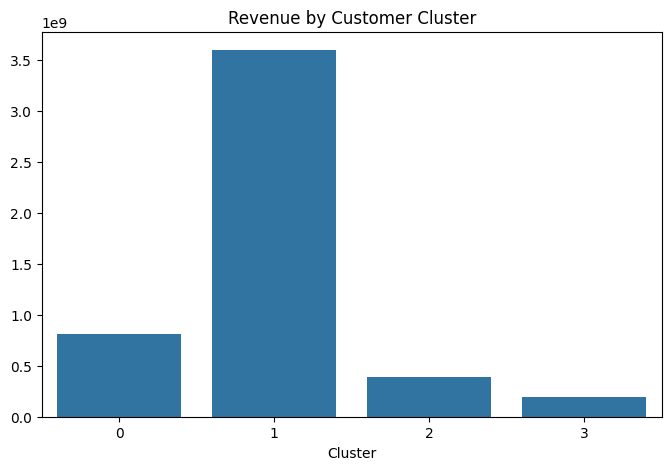

In [29]:
cluster_revenue = rfm.groupby('Cluster')['Monetary'].sum()

cluster_revenue

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_revenue.index,
    y=cluster_revenue.values
)

plt.title("Revenue by Customer Cluster")
plt.show()

## Recency Distribution

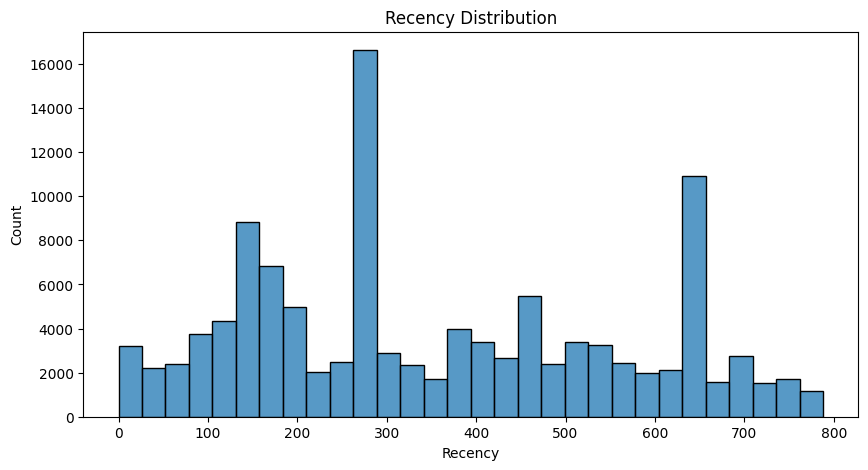

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Recency'], bins=30)

plt.title("Recency Distribution")
plt.show()

## Frequency Distribution

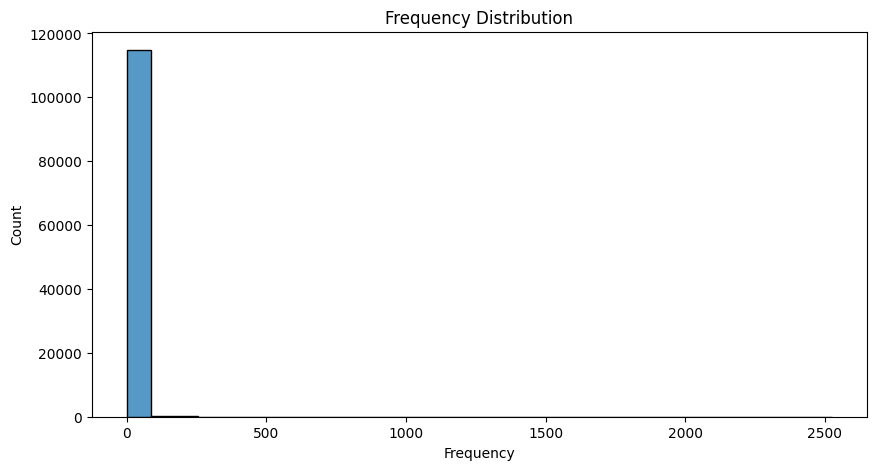

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Frequency'], bins=30)

plt.title("Frequency Distribution")
plt.show()

## Monetary Distribution

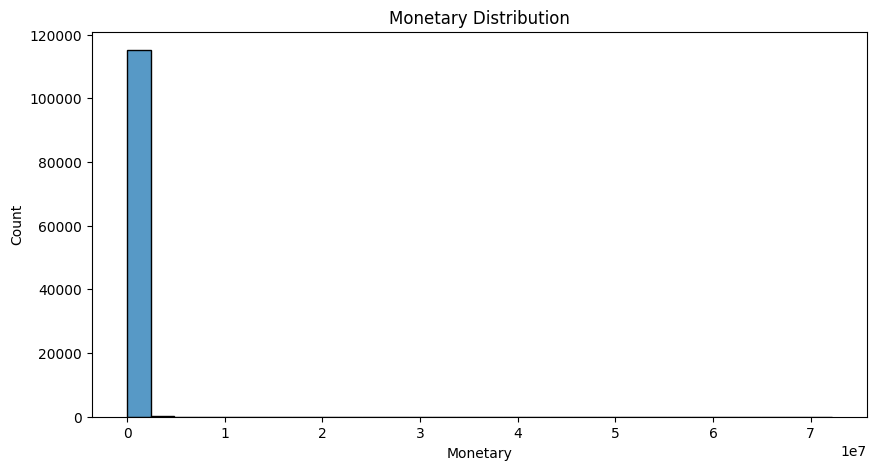

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Monetary'], bins=30)

plt.title("Monetary Distribution")
plt.show()

## Save Model

In [33]:
joblib.dump(kmeans, 'customer_segmentation_model.pkl')

['customer_segmentation_model.pkl']